# Logistic Regression Model

## 📌 Notebook Overview

This notebook implements and evaluates [**Logistic Regression models**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) to predict multiple clinical outcomes in neuroblastoma using gene expression data from two platforms:

- RNA-Seq
- Microarray

The objective is to compare model performance across:
1. Different clinical outcomes
2. Different transcriptomic platforms

---

## 🎯 Objectives

- Preprocess gene expression datasets using custom utility functions.
- Train Logistic Regression models with proper handling of class imbalance.
- Evaluate performance using multiple classification metrics.
- Compare RNA-Seq vs Microarray predictive performance.
- Visualize ROC curves and performance metrics.

---

## ⚙️ Methodology

### 1️⃣ Data Loading & Preprocessing
- Data is loaded using a custom `get_data()` function.
- Training and test splits are pre-defined.
- Features are standardized using `StandardScaler`.

### 2️⃣ Handling Class Imbalance
- SMOTE (Synthetic Minority Over-sampling Technique) is applied within a pipeline to balance classes in the training set.

### 3️⃣ Model Training
- Logistic Regression (`max_iter=1000`, `random_state=42`)
- Implemented within an imbalanced-learn pipeline:
  - Scaling
  - SMOTE
  - Logistic Regression

### 4️⃣ Model Evaluation
Models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Cross-validation (Stratified K-Fold) is used to check robustness and potential data leakage.

---

## 📊 Visualisations

The notebook generates:

- ROC curve comparisons (RNA-Seq vs Microarray)
- Grouped bar charts comparing performance metrics across:
  - Outcomes
  - Platforms

---

## 🔎 Key Comparisons

This notebook allows investigation of:

- Does RNA-Seq outperform Microarray for specific outcomes?
- Which clinical outcome is most predictable?
- How stable is Logistic Regression across platforms?

---

## 📁 Structure of Notebook

1. Import modules
2. Trial model on "Death from Disease"
3. Cross-validation check
4. Train models on all outcomes (RNA-Seq & Microarray)
5. Plot ROC curves
6. Plot performance comparisons

---

This notebook establishes a baseline predictive framework for transcriptomic-based outcome prediction and platform comparison.

## Import modules

In [1]:
!pip install -q scanpy anndata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 33.2 MB/s eta 0:00:00


In [2]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"

import sys
sys.path.append('/content/drive/MyDrive/projects/ml_module/neuroblastoma_predictive_modelling/')

# Data handling
import pandas as pd
import numpy as np

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Custom function
from utils import get_data

## Trial on Death From Disease Outcome

In [3]:
X_train, X_test, y_train, y_test = get_data('rnaseq', 'death_from_disease')

  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - Death From Disease
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0: 154, 1: 40}
  Test outcome distribution:  {0: 39, 1: 10}


In [4]:
X_train

,A1BG,A1CF,A2M,AACSP1,AADAC,ABCA12,ABCA8,ABCB11,ABCB4,ABCC2,...,ZFP36,ZG16,ZIC1,ZIC2,ZIC3,ZIC5,ZNF385B,ZNF664,ZNF664-FAM101A,ZNFX1-AS1
NB297,8.397936,3.338918,9.026266,3.184915,5.341897,0.116456,2.558980,2.221596,3.756255,3.801738,...,5.114138,1.947737,0.000000,0.0,0.000000,0.000000,2.231110,5.042469,0.224712,5.310424
NB209,1.806662,0.005419,6.004879,3.558476,0.034047,0.192767,0.421682,0.123370,1.039181,0.135225,...,6.910241,0.000000,0.009733,0.0,0.000000,0.000000,0.000000,5.236451,1.182673,6.001795
NB043,1.306875,0.030836,6.074199,2.340400,0.000000,0.203101,0.147723,0.019613,0.419086,0.278613,...,4.364411,0.000000,0.000000,0.0,0.000000,0.000000,0.667125,5.105255,1.014805,5.214964
NB493,1.649027,0.005746,5.223052,4.457667,0.000000,3.048855,0.018776,0.000000,0.731000,0.246387,...,4.438326,0.000000,0.000000,0.0,0.000000,0.000000,0.083393,5.248565,0.948311,5.001298
NB103,1.701775,0.025598,5.979589,1.520819,0.059815,0.799789,0.280371,0.018995,0.629763,0.070420,...,5.070879,0.000000,0.000000,0.0,0.206363,0.000000,0.504105,4.637755,0.801708,4.429770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NB389,2.540464,0.006285,4.539655,0.441973,0.000000,1.428925,0.060731,0.000000,0.369153,0.459315,...,2.900413,0.000000,0.000000,0.0,0.000000,0.088021,0.159851,5.269478,1.125757,5.965348
NB427,2.797397,0.894051,6.401320,2.674619,2.436474,0.144003,0.928639,0.066745,0.863651,0.872535,...,4.227048,0.037998,0.000000,0.0,0.000000,0.000000,1.098103,5.208587,0.512682,5.467563
NB077,1.382025,0.000000,6.033088,4.656044,0.030661,0.044815,1.913841,0.074774,0.450556,0.271409,...,5.060986,0.000000,0.497026,0.0,0.000000,0.000000,0.017978,5.241833,0.461900,5.045679
NB475,2.547615,0.024264,3.913445,1.907379,0.000000,2.897200,0.096953,0.000000,0.288843,0.099133,...,2.540508,0.000000,0.000000,0.0,0.000000,0.000000,3.022725,4.718942,0.213342,7.510614


In [5]:
y_train

,0
NB297,0
NB209,0
NB043,0
NB493,0
NB103,0
...,...
NB389,0
NB427,0
NB077,0
NB475,1


In [6]:
# Create pipeline with scaler, SMOTE, and model
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        random_state=42,
        #class_weight='balanced', # using smote instead
        max_iter=1000
    ))
])

# Fit pipeline
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Performance metrics
print("=" * 50)
print("LOGISTIC REGRESSION - PERFORMANCE METRICS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)']))

LOGISTIC REGRESSION - PERFORMANCE METRICS

Accuracy:  0.8163
Precision: 0.5333
Recall:    0.8000
F1-Score:  0.6400
ROC-AUC:   0.8769

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Survived (0)       0.94      0.82      0.88        39
    Died (1)       0.53      0.80      0.64        10

    accuracy                           0.82        49
   macro avg       0.74      0.81      0.76        49
weighted avg       0.86      0.82      0.83        49



### Interpretation:
**ROC-AUC of 0.877** indicates strong discriminative ability between survivors and
non-survivors using gene expression alone.

The model prioritises **sensitivity over precision** for the death class (recall=0.80,
precision=0.53) — catching 8/10 true deaths at the cost of some false positives.
This is a clinically acceptable trade-off, as missing a true death is more costly
than over-flagging survivors.

In [7]:
# Check cross-validation — if leakage, CV scores will vary wildly
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"CV ROC-AUC scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

CV ROC-AUC scores: [0.875      0.9233871  0.73790323 0.79435484 0.80416667]
Mean: 0.8270 +/- 0.0650


## Train models on all outcomes

In [8]:
outcomes = ['death_from_disease', 'high_risk', 'progression']
platforms = ['rnaseq', 'microarray']

all_results = []
roc_data = {}

print("=" * 70)
print("TRAINING LOGISTIC REGRESSION MODELS")
print("=" * 70)

for outcome in outcomes:
    print(f"\n{'=' * 70}")
    print(f"OUTCOME: {outcome.replace('_', ' ').upper()}")
    print(f"{'=' * 70}")

    roc_data[outcome] = {}

    for platform in platforms:
        print(f"\n--- {platform.upper()} ---")

        # Load data — already split, no train_test_split needed
        X_train, X_test, y_train, y_test = get_data(platform, outcome)

        # Create pipeline with scaler, SMOTE, and model
        pipeline = ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)),
            ('model', LogisticRegression(
                random_state=42,
                #class_weight='balanced', # using smote instead
                max_iter=1000
            ))
        ])

        # Fit pipeline
        pipeline.fit(X_train, y_train)

        # Predict
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_proba)

        # Store results
        all_results.append({
            'Outcome': outcome.replace('_', ' ').title(),
            'Platform': platform.upper(),
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc,
            'Samples': len(y_train) + len(y_test)
        })

        # Store ROC curve data
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_data[outcome][platform] = {
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc,
            'y_val': y_test,
            'y_proba': y_proba
        }

        # Print metrics
        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  ROC-AUC:   {roc_auc:.4f}")

results_df = pd.DataFrame(all_results)

print("\n" + "=" * 70)
print("SUMMARY OF ALL RESULTS")
print("=" * 70)
print(results_df.to_string(index=False))

TRAINING LOGISTIC REGRESSION MODELS

OUTCOME: DEATH FROM DISEASE

--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - Death From Disease
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0: 154, 1: 40}
  Test outcome distribution:  {0: 39, 1: 10}
  Accuracy:  0.8163
  Precision: 0.5333
  Recall:    0.8000
  F1-Score:  0.6400
  ROC-AUC:   0.8769

--- MICROARRAY ---
  After QC filtering: 246 samples, 43291 genes
  HVG selected from train: 2000 genes

MICROARRAY - Death From Disease
  Train samples: 196 | Test samples: 50
  Total features: 2000
  Train outcome distribution: {0: 155, 1: 41}
  Test outcome distribution:  {0: 40, 1: 10}
  Accuracy:  0.8400
  Precision: 0.5833
  Recall:    0.7000
  F1-Score:  0.6364
  ROC-AUC:   0.8825

OUTCOME: HIGH RISK

--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - High Risk
  Train samples: 1

## Plot ROC curves

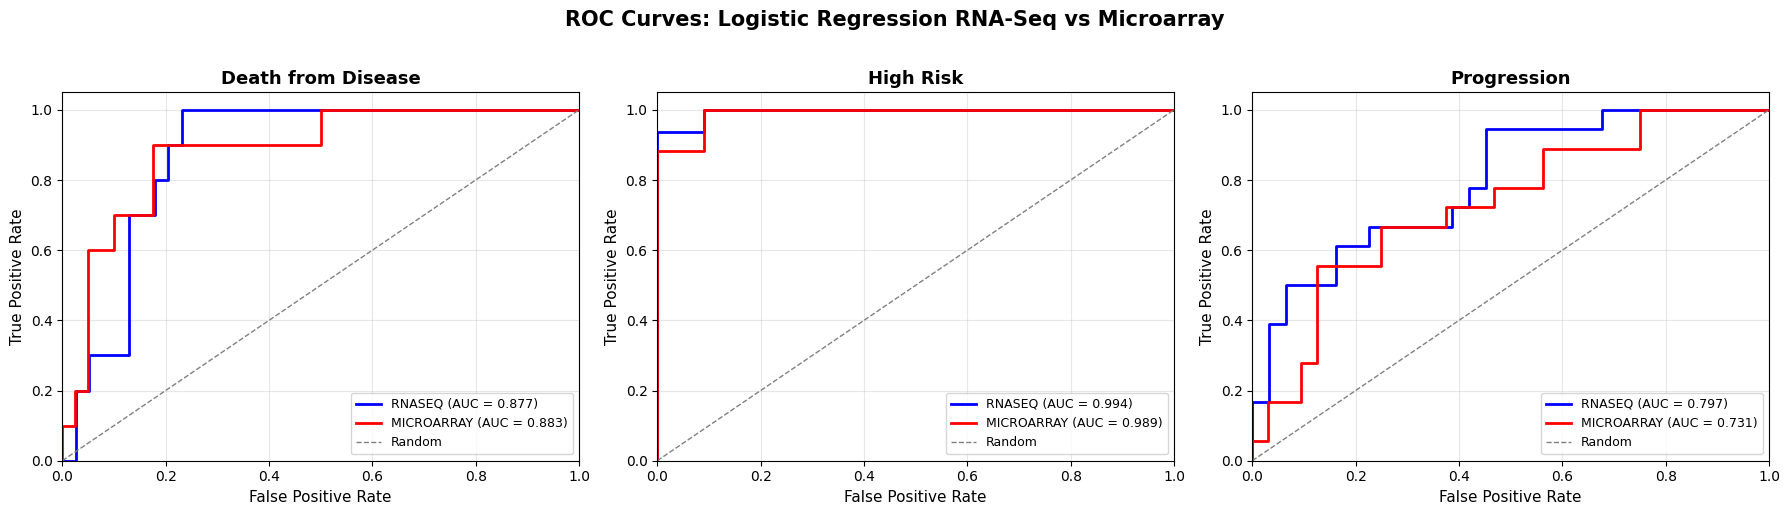

In [9]:
# Create ROC curve comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

outcome_titles = {
    'death_from_disease': 'Death from Disease',
    'high_risk': 'High Risk',
    'progression': 'Progression'
}

colors = {
    'rnaseq': 'blue',
    'microarray': 'red'
}

for idx, outcome in enumerate(outcomes):
    ax = axes[idx]

    # Plot ROC curves for both platforms
    for platform in platforms:
        data = roc_data[outcome][platform]
        ax.plot(data['fpr'], data['tpr'],
                color=colors[platform],
                lw=2,
                label=f"{platform.upper()} (AUC = {data['auc']:.3f})")

    # Plot diagonal (random classifier)
    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')

    # Formatting
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(outcome_titles[outcome], fontsize=13, fontweight='bold')
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: Logistic Regression RNA-Seq vs Microarray', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('roc_comparison_rnaseq_vs_microarray.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot performance metrics

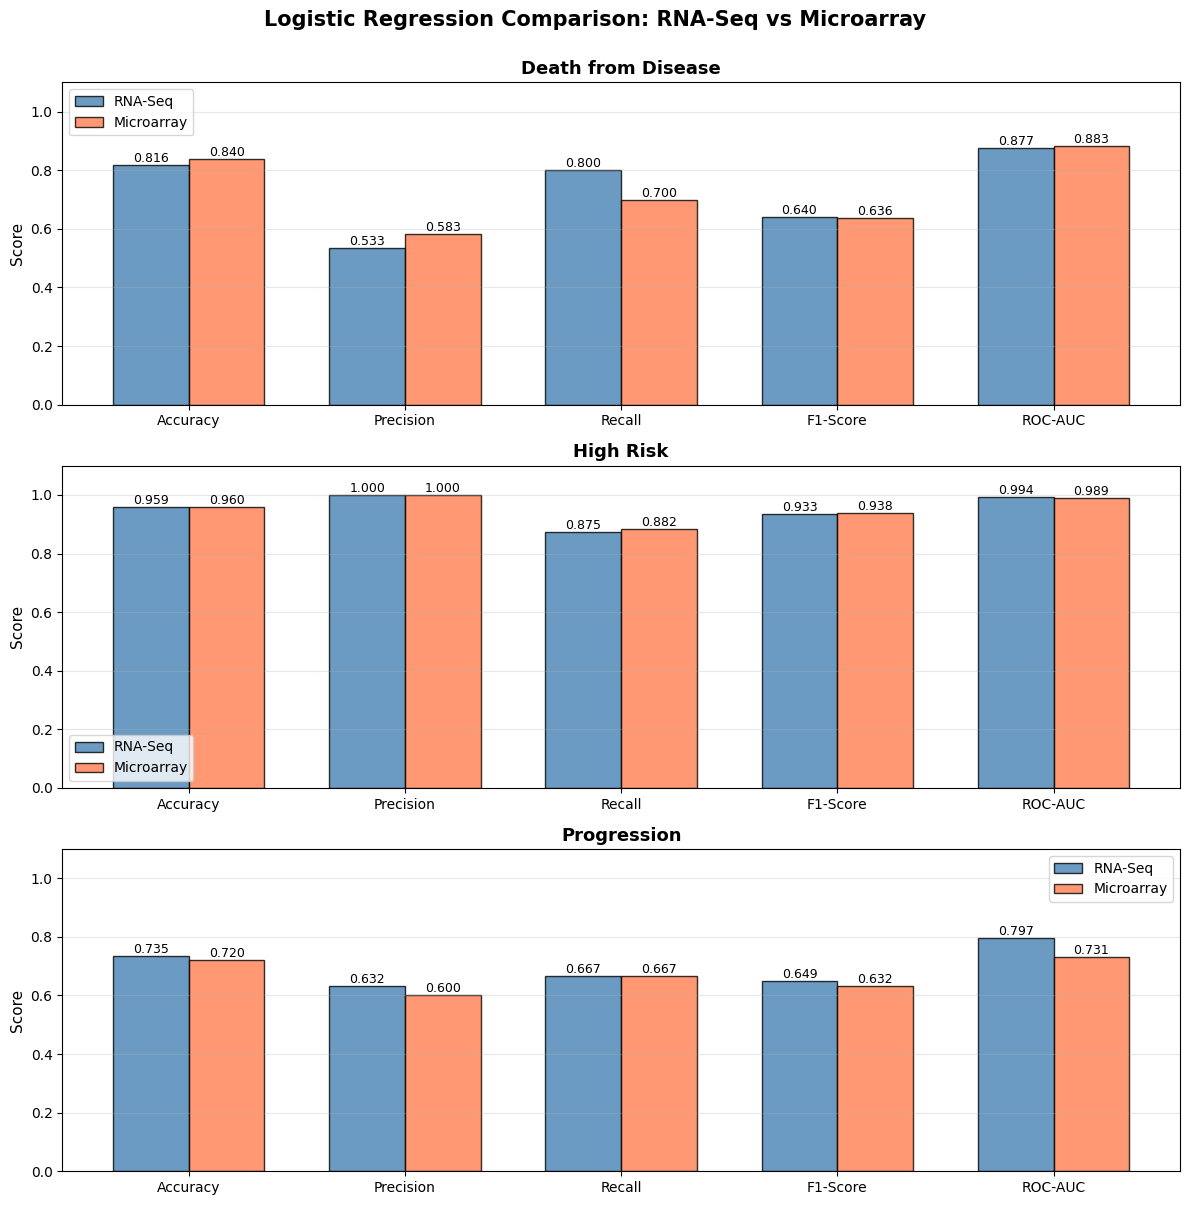

In [10]:
# Grouped Bar Chart - All Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(len(outcomes), 1, figsize=(12, 12))

for idx, outcome in enumerate(outcomes):
    ax = axes[idx]

    # Filter data for this outcome
    outcome_data = results_df[results_df['Outcome'] == outcome.replace('_', ' ').title()]

    # Prepare data for plotting
    x = np.arange(len(metrics))
    width = 0.35

    rnaseq_values = outcome_data[outcome_data['Platform'] == 'RNASEQ'][metrics].values[0]
    microarray_values = outcome_data[outcome_data['Platform'] == 'MICROARRAY'][metrics].values[0]

    # Plot bars
    bars1 = ax.bar(x - width/2, rnaseq_values, width, label='RNA-Seq',
                   color='steelblue', alpha=0.8, edgecolor='black')
    bars2 = ax.bar(x + width/2, microarray_values, width, label='Microarray',
                   color='coral', alpha=0.8, edgecolor='black')

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9)

    # Formatting
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(outcome_titles[outcome], fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.legend(fontsize=10)
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Logistic Regression Comparison: RNA-Seq vs Microarray',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
#plt.savefig('performance_comparison_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation:


### Death from Disease
Both platforms show comparable performance (AUC: RNASEQ=0.877, MICROARRAY=0.883),
with high recall for the death class (0.80 and 0.70 respectively) at the cost of
lower precision (~0.53-0.58). The model prioritises sensitivity over specificity,
which is clinically appropriate for mortality prediction. Small test set (10 positive
cases) means estimates should be interpreted cautiously.

### High Risk
The strongest outcome across both platforms (AUC: RNASEQ=0.994, MICROARRAY=0.989),
with perfect precision (1.0) — every sample predicted as high risk truly was high
risk. The near-perfect AUC suggests gene expression strongly encodes neuroblastoma
risk classification, likely reflecting known transcriptional signatures of MYCN
amplification and other risk-associated pathways.

### Progression
The weakest outcome for logistic regression (AUC: RNASEQ=0.797, MICROARRAY=0.731),
with moderate precision and recall (~0.63-0.67) for both platforms. The lower
performance suggests disease progression has a more complex, potentially non-linear
transcriptional signature that a linear model struggles to capture. RNA-Seq
outperforms microarray here, suggesting RNA-Seq better captures progression-associated
expression changes.

### Platform Comparison
Both platforms perform similarly overall, with microarray marginally better for death
prediction and RNA-Seq better for progression. The consistency across platforms
suggests the predictive signal is biologically robust rather than platform-specific.

In [11]:
# Save results for plotting notebook
results_df['Model'] = 'Logistic Regression'  # add model name
results_df.to_csv('/content/drive/MyDrive/projects/ml_module/neuroblastoma_predictive_modelling/results_lr.csv', index=False)